# Amateur Radio Plot Ham RTI
*Nathaniel A. Frissell, W2NAF, 27 November 2024*

In [1]:
import os
import datetime
import pickle
import bz2

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

# from tqdm.notebook import tqdm
import tqdm

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [2]:
plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']    = 'bold'
plt.rcParams['axes.titleweight']    = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['grid.linestyle'] = ':'

In [3]:
region_dct = {}
region_dct['World'] = tmp = {}
tmp['xlim'] = (-180, 180)
tmp['ylim'] = ( -90,  90)

# Continental US (CONUS)
region_dct['CONUS'] = tmp = {}
tmp['xlim'] = (-130,-56)
tmp['ylim'] = (  20, 55)

# CONUS + Canada
region_dct['CONUSCanada'] = tmp = {}
tmp['xlim'] = (-130, -56)
tmp['ylim'] = (  20,  80)

In [4]:
date   = datetime.datetime(2018,12,15)
frange = (14.000e6,14.350e6)

# Load Data

In [5]:
ham_dir   = os.path.join('output','iri2016')
ham_fname = f'20181215.1200-20181216.0000_iri2016.spot.csv'
ham_fpath = os.path.join(ham_dir,ham_fname)
print(ham_fpath)

output/iri2016/20181215.1200-20181216.0000_iri2016.spot.csv


In [6]:
df = pd.read_csv(ham_fpath,parse_dates=[0])

In [7]:
df

,date,call_sign_tx,txlat,txlon,call_sign_rx,rxlat,rxlon,tfreq,sn,smode,ssrc,pthlen,latcen,loncen
0,2018-12-15 12:00:00,1N8KHW,36.145833,-95.958333,N4JPG,34.1458,-77.875000,14.0,NaN,Raytrace,iri2016,1656,35.483686,-86.804625
1,2018-12-15 12:00:00,N0FMX,44.020833,-92.541667,WA3IMF,39.2896,-77.220800,14.0,NaN,Raytrace,iri2016,1374,41.910066,-84.598032
2,2018-12-15 12:00:00,VE9HU,45.000000,-76.000000,K_SWL_OMAHA,41.2708,-95.958300,14.0,NaN,Raytrace,iri2016,1666,43.570992,-86.286648
3,2018-12-15 12:00:00,N0EO,46.500000,-93.000000,WA1ECA,41.7396,-73.187500,14.0,NaN,Raytrace,iri2016,1662,44.549310,-82.690425
4,2018-12-15 12:00:00,VE9H,45.000000,-76.000000,KD0YTE,40.1896,-92.570800,14.0,NaN,Raytrace,iri2016,1454,42.893998,-84.607603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100114,2018-12-16 00:00:00,K9NW,41.500000,-85.000000,K5HX,30.1896,-95.420800,14.0,NaN,Raytrace,iri2016,1567,35.956908,-90.584156
100115,2018-12-16 00:00:00,N2TIM,44.780000,-89.680000,NY0J,36.6042,-93.291700,14.0,NaN,Raytrace,iri2016,958,40.706118,-91.596866
100116,2018-12-16 00:00:00,N9MDS,42.260400,-88.129200,W2COS,43.5000,-77.000000,14.0,NaN,Raytrace,iri2016,916,43.015161,-82.620677
100117,2018-12-16 00:00:00,W6SX,37.580000,-118.840000,N6XN,38.5000,-123.000000,14.0,NaN,Raytrace,iri2016,378,38.058328,-120.906928


In [8]:
sDate = datetime.datetime(2018,12,15,12)
eDate = datetime.datetime(2018,12,16)
dt    = datetime.timedelta(minutes=10)

dx    = dt.total_seconds()

ymin  = 0
ymax  = 3000
dy    = 20.

datetimes = [sDate]
while datetimes[-1] < eDate:
    new_time = datetimes[-1] + dt
    datetimes.append(new_time)

xbins = [(x-datetimes[0]).total_seconds() for x in datetimes]
ybins = np.arange(ymin,ymax,dy)

df['dt_secs'] = (df['date'] - sDate).apply(lambda x:x.total_seconds())

In [9]:
# # Add one more bound to each bin...
# datetimes.append(datetimes[-1]+dt)
# xbins.append(xbins[-1]+dx)
# ybins.append(ybins[-1]+dy)

# Calculate histogram
xkey    = 'dt_secs'
ykey    = 'pthlen'
xvals   = df[xkey].values
yvals   = df[ykey].values
hist, xb, yb = np.histogram2d(xvals,yvals, bins=[xbins, ybins])

In [10]:
hist

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 3.],
       [0., 0., 0., ..., 4., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 2., 0., 0.],
       [0., 0., 0., ..., 0., 2., 0.]])

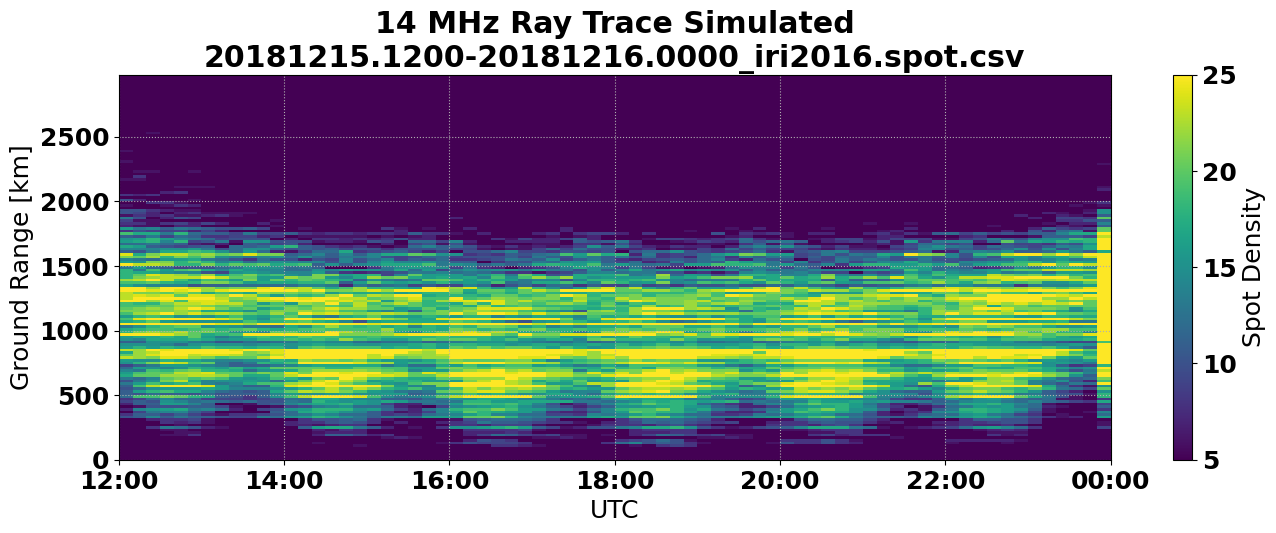

In [11]:
vmin = 5
vmax = 25
fig  = plt.figure(figsize=(16,5))
ax   = fig.add_subplot(111)
mpbl = ax.pcolormesh(datetimes, yb, hist.T,vmin=vmin,vmax=vmax)
fig.colorbar(mpbl,label='Spot Density')
# plt.xlim(datetime.datetime(2018,12,15,14), datetime.datetime(2018,12,15,22))
# plt.ylim(1000,1500)

plt.xlabel('UTC')
plt.ylabel('Ground Range [km]')

xts = ax.get_xticks()

xtls = []
for xt in xts:
    xt_date = mpl.dates.num2date(xt)
    xtls.append(xt_date.strftime('%H:%M'))

ax.set_xticks(xts)
ax.set_xticklabels(xtls)

title = []
title.append('14 MHz Ray Trace Simulated')
title.append(ham_fname)
ax.set_title('\n'.join(title))

plt.show()